## Отчет по лабораторной работе: Регрессия и метод главных компонент

### 1 Введение

Цель работы: изучение основ линейной регрессии, построение простейших моделей, проведение обучения на реальных данных и оценка качества. В ходе работы будет проведена загрузка и предобработка данных, анализ мультиколлинеарности, построение моделей линейной, Lasso и Ridge регрессии, а также применение метода главных компонент (PCA) для снижения размерности.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings('ignore')

# Названия колонок согласно описанию датасета
columns = ['VendorName', 'ModelName', 'MYCT', 'MMIN', 'MMAX', 'CACH', 'CHMIN', 'CHMAX', 'PRP', 'ERP']

# Загрузка датасета
df = pd.read_csv('machine.data', names=columns)

# Удаление категориальных признаков и переменной-утечки (ERP)
df = df.drop(columns=['VendorName', 'ModelName', 'ERP'])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   MYCT    209 non-null    int64
 1   MMIN    209 non-null    int64
 2   MMAX    209 non-null    int64
 3   CACH    209 non-null    int64
 4   CHMIN   209 non-null    int64
 5   CHMAX   209 non-null    int64
 6   PRP     209 non-null    int64
dtypes: int64(7)
memory usage: 11.6 KB


### 2 Описание датасета

В работе используется набор данных о производительности процессоров. Датасет содержит 209 экземпляров. В наборе представлены 10 атрибутов, из которых 6 являются предиктивными независимыми переменными (MYCT, MMIN, MMAX, CACH, CHMIN, CHMAX), а целевой переменной выступает PRP (опубликованная относительная производительность). Переменная ERP представляет собой оцененную производительность из оригинальной статьи, рассчитанную авторами с помощью их собственной линейной регрессии. Пропущенные значения в данных отсутствуют. Целевая переменная PRP является непрерывной, поэтому использование логистической регрессии не требуется.

Согласно постановке задачи, категориальные переменные (название производителя и название модели) будут удалены из выборки. Атрибут ERP также исключается, так как является предсказанием целевой переменной из оригинального исследования.

#### 2.1 Подробное описание переменных таблицы Hardware

После удаления текстовых данных и переменной-утечки, в нашем датасете остались 7 числовых характеристик процессоров. Ниже приведено их подробное описание:

| Оригинальное название | Название на русском | Описание |
| :--- | :--- | :--- |
| **MYCT** | Время цикла машины | Время машинного цикла в наносекундах. |
| **MMIN** | Мин. оперативная память | Минимальный объем основной памяти (ОЗУ) в килобайтах. |
| **MMAX** | Макс. оперативная память | Максимальный объем основной памяти (ОЗУ) в килобайтах. |
| **CACH** | Кэш-память | Объем кэш-памяти процессора в килобайтах. |
| **CHMIN** | Мин. количество каналов | Минимальное поддерживаемое количество каналов (в штуках). |
| **CHMAX** | Макс. количество каналов | Максимальное поддерживаемое количество каналов (в штуках). |
| **PRP** | Производительность *(Целевая)*| Опубликованная относительная производительность процессора. Эту величину наша модель должна научиться предсказывать. |

#### 2.2 Анализ распределения признаков
В данном блоке мы визуализируем распределение целевой переменной PRP и предиктивных признаков.

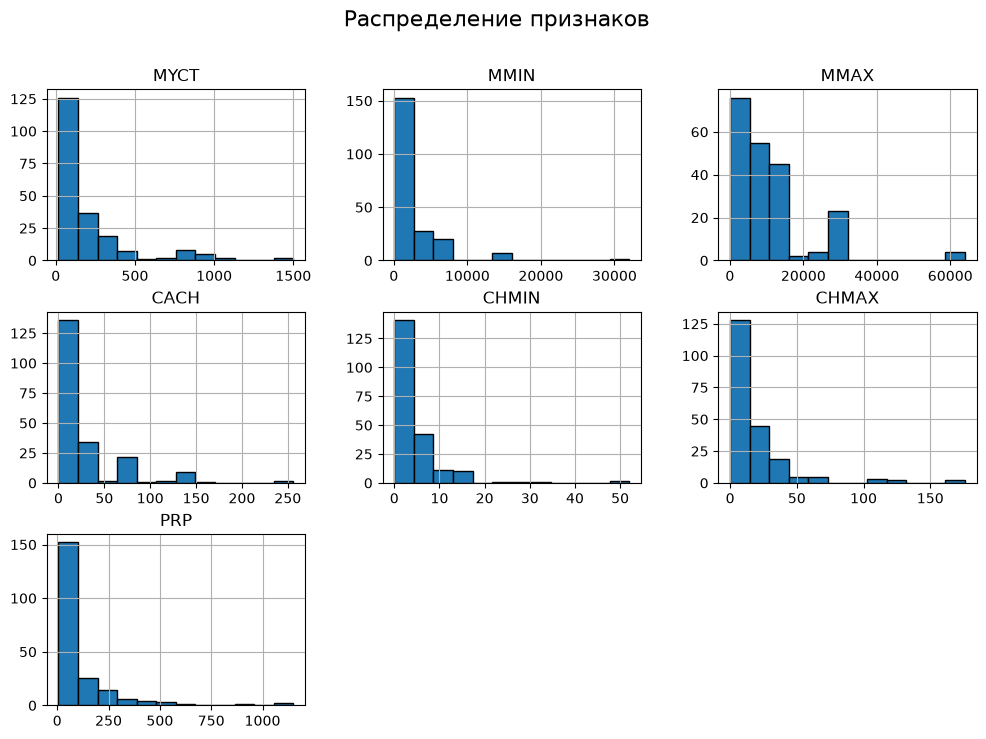

In [18]:
# Визуализация распределений
df.hist(bins=12, figsize=(12, 8), edgecolor='black')
plt.suptitle('Распределение признаков', fontsize=16)
plt.show()

Как видно по гистограммам, все значения переменных сконцентрированы ближе к нулю по оси абсцисс, следовательно, мы иммем правую асимметрию. Большинство переменных имеют положительный эксцесс, что отражается резким переходом между первыми и вторыми столбцами соответсвующей гистрограммы, кроме максимальной оперативной памяти (MMAX): здесь переход более плавный.

#### 2.3 Корреляционная матрица и расчет коэффициента инфляции дисперсии
Матрица корреляций поможет предварительно оценить взаимосвязи между переменными, а расчет коэффициента инфляции дисперсии (VIF) позволит сделать выводы о наличии мультиколлинеарности. Данные не содержат пропусков, поэтому заполнение или удаление пустых строк не требуется.

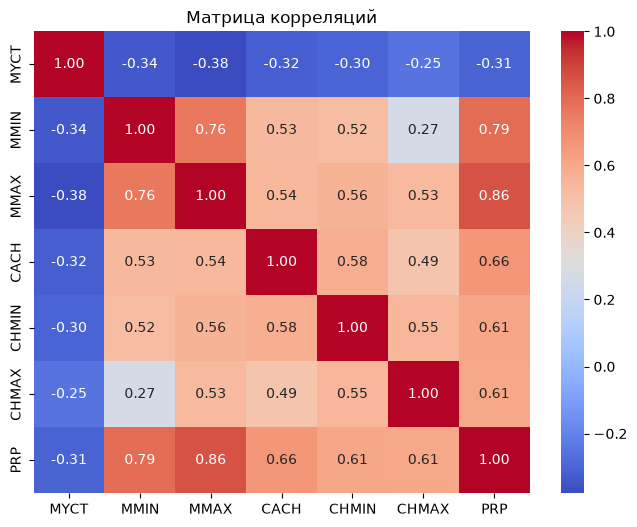

  Feature       VIF
0    MYCT  1.201644
1    MMIN  2.902002
2    MMAX  3.274002
3    CACH  1.858349
4   CHMIN  1.966234
5   CHMAX  1.891392


In [19]:
# Корреляционная матрица
plt.figure(figsize=(8, 6))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Матрица корреляций")
plt.show()

# Расчет VIF для выявления мультиколлинеарности
X_vif = df.drop(columns=['PRP'])
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
print(vif_data)

Как видно из корреляционной матрицы, некоторые признаки сильно коррелируют друг с другом (например, `MMIN` и `MMAX`). Все переменные почти плохо коллерируют (в среднем -0.3) с `MYCT` (время цикла машины) и имеют обратную корреляцию. Минимальная оперативная память `MMIN` плохо коллерирует с максимальным количеством каналов `CHMAX`. Это объясняется архитектурой ЭВМ: параметр `MMIN` задает базовый порог для запуска операционной системы на минимальной конфигурации, тогда как `CHMAX` определяет предел масштабируемости системы по вводу-выводу (I/O). В реальных условиях конфигурация по каналам ввода-вывода подбиралась под специфические задачи клиента и могла быть высокой даже при стартовом (минимальном) объеме ОЗУ. Значения `VIF` выше 5-10 подтверждают наличие мультиколлинеарности.

### 3 Подготовка данных


В данном разделе подробно изложены процедуры предобработки данных перед их передачей в регрессионные модели:

1. **Исключение неинформативных и категориальных признаков:**
   - Категориальные текстовые переменные `VendorName` и `ModelName` удалены.
   - Переменная `ERP` (расчетная производительность из статьи) исключена во избежание утечки целевого признака (*data leakage*).

2. **Проверка и обработка пропущенных значений (Missing Values):**
   - Выполнена проверка датасета с помощью метода `.isna().sum()`.
   - Пропущенных значений в данных не обнаружено (все 209 строк имеют `0` пропусков), поэтому процедуры импутации (заполнения медианой/средним) или удаления строк не потребовались.

3. **Разделение выборки на обучающую и тестовую (Train/Test Split):**
   - Данные разделены на матрицу признаков $X$ и целевой вектор $y$ (`PRP`).
   - Использована функция `train_test_split` для разбиения в соотношении **80/20** (80% — обучающая выборка `train`, 20% — тестовая выборка `test`) с фиксацией `random_state=42` для воспроизводимости результатов.

4. **Нормализация / Стандартизация данных (Standardization):**
   - Признаки в датасете существенно различаются по масштабу и единицам измерения (наносекунды, килобайты, количества каналов). Чтобы признакам с большими значениями не отдавался искусственный приоритет, проведена стандартизация (`StandardScaler`):
     $$z = \frac{x - \mu}{\sigma}$$
   - Настройка масштабирования (`fit`) проводилась строго на обучающей выборке `X_train`, после чего преобразование (`transform`) было применено к `X_train` и `X_test`.

In [20]:
# 1. Проверка на наличие пропущенных значений
print("=== 1. Проверка пропусков ===")
print(df.isna().sum())

# 2. Разделение на признаки (X) и целевую переменную (y)
X = df.drop(columns=['PRP'])
y = df['PRP']

# 3. Разделение выборки на train / test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\n=== 2. Размеры выборок после разделения ===")
print(f"Обучающая выборка (X_train): {X_train.shape[0]} объектов, {X_train.shape[1]} признаков")
print(f"Тестовая выборка (X_test):   {X_test.shape[0]} объектов, {X_test.shape[1]} признаков")

# 4. Нормализация (стандартизация) признаков
scaler = StandardScaler()

# Fit на train, transform на train и test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Отображение результата стандартизации для проверки
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
print("\n=== 3. Первые 5 строк обучающей выборки ПОСЛЕ стандартизации ===")
print(X_train_scaled_df.head())

=== 1. Проверка пропусков ===
MYCT     0
MMIN     0
MMAX     0
CACH     0
CHMIN    0
CHMAX    0
PRP      0
dtype: int64

=== 2. Размеры выборок после разделения ===
Обучающая выборка (X_train): 167 объектов, 6 признаков
Тестовая выборка (X_test):   42 объектов, 6 признаков

=== 3. Первые 5 строк обучающей выборки ПОСЛЕ стандартизации ===
       MYCT      MMIN      MMAX      CACH     CHMIN     CHMAX
0 -0.624967  1.551358  0.419613  0.176130  0.653103 -0.055738
1 -0.677359  3.930080  1.898340  0.948268  0.653103  0.285849
2 -0.662390  1.551358  4.855794  2.492545  1.348913  6.776010
3 -0.381716 -0.530024 -0.689432 -0.596009 -0.216659  0.285849
4 -0.662390  3.930080  1.898340  5.581098  2.044723  0.285849


### 4 Ход работы

#### 4.1 Описание моделей и исследование регрессоров до устранения мультиколлинеарности

В работе исследуются три алгоритма линейной регрессии:
1. **Классическая линейная регрессия (МНК / OLS):** 
    <p>Находит коэффициенты путем минимизации суммы квадратов ошибок. Модель чувствительна к мультиколлинеарности — при сильной связи между признаками матрица $(X^T X)$ становится близится к вырожденной, что приводит к раздуванию дисперсии оценок коэффициентов.</p>
2. **Гребневая регрессия (Ridge / $L_2$-регуляризация):** 
    <p>Добавляет штраф за крупный размер весов, минимизируя функционал $MSE + \alpha \sum \beta_j^2$. Это стабилизирует решение при наличии мультиколлинеарности, «сжимая» коэффициенты к нулю.</p>
3. **Регрессия Лассо (Lasso / $L_1$-регуляризация):** 
    <p>Добавляет штраф на абсолютные значения весов: $MSE + \alpha \sum \vert{}\beta_j\vert{}$. Позволяет обнулять весы наименее важных или дублирующих признаков, фактически выполняя автоматический отбор факторов.</p>

**Метрики качества моделей:**
- **RMSE (Root Mean Square Error):** $\sqrt{\frac{1}{n}\sum (y_i - \hat{y}_i)^2}$ — штрафует за крупные отклонения, измеряется в единицах целевой переменной.
- **$R^2$ (Коэффициент детерминации):** $1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$ — показывает долю дисперсии целевой переменной, объясненную моделью (чем ближе к $1$, тем лучше).
- **MAPE (Mean Absolute Percentage Error):** $\frac{100\%}{n} \sum \left\vert{}\frac{y_i - \hat{y}_i}{y_i}\right\vert{}$ — средняя относительная ошибка в процентах.

Оценка проводилась с использованием $5$-кратной кросс-валидации (`cv=5`) на обучающей выборке.

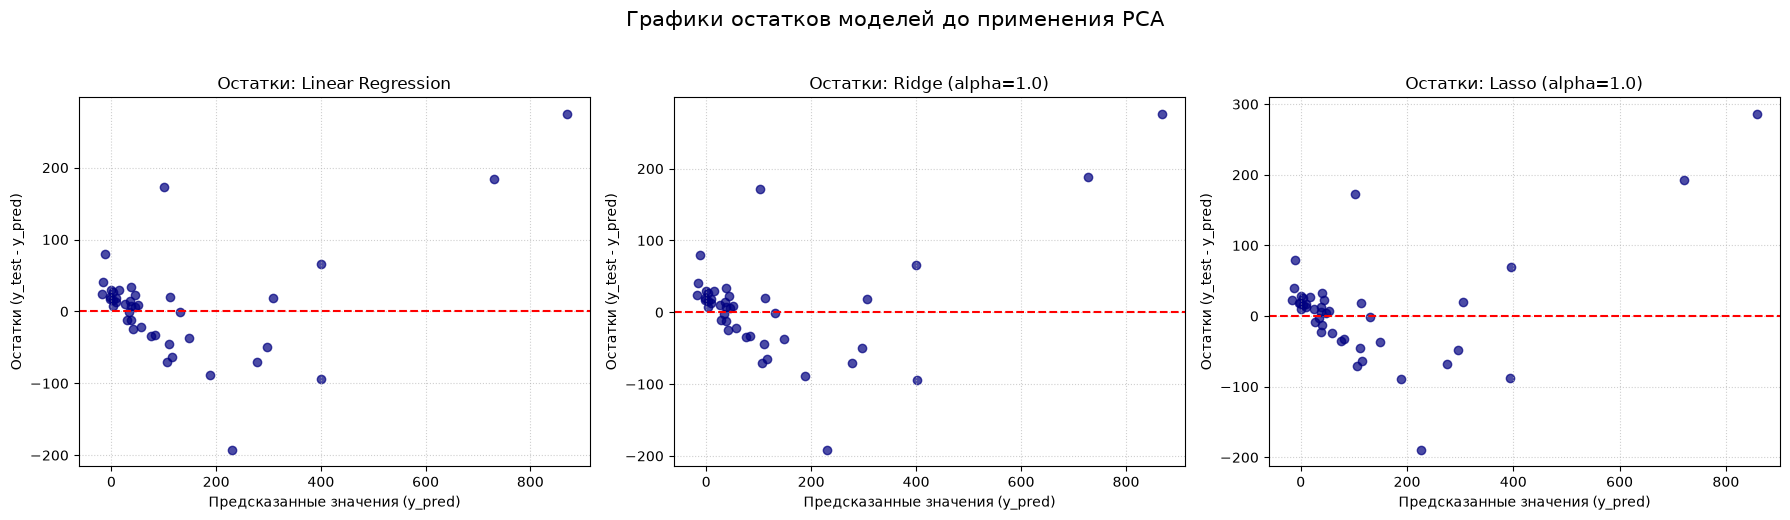

=== Метрики качества моделей на исходных признаках ===
           Модель      RMSE       R²  MAPE (%)    CV R²
Linear Regression 75.053768 0.889346 80.269270 0.650822
Ridge (alpha=1.0) 75.248993 0.888769 79.612390 0.655491
Lasso (alpha=1.0) 76.043345 0.886408 78.109055 0.662148


In [21]:
# Обучение исходных моделей на стандартизованных данных
models = {
    "Linear Regression": LinearRegression(),
    "Ridge (alpha=1.0)": Ridge(alpha=1.0),
    "Lasso (alpha=1.0)": Lasso(alpha=1.0, random_state=42)
}

results_before = []

# Построение графиков остатков
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models.items()):
    # Оценка на кросс-валидации (R2)
    cv_r2 = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2').mean()
    
    # Обучение модели и предсказание на тестовой выборке
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    # Расчет метрик качества
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100  # в процентах
    
    results_before.append({
        'Модель': name,
        'RMSE': rmse,
        'R²': r2,
        'MAPE (%)': mape,
        'CV R²': cv_r2
    })
    
    # Ошибки (остатки)
    residuals = y_test - y_pred
    
    # График остатков
    axes[idx].scatter(y_pred, residuals, alpha=0.7, color='navy')
    axes[idx].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    axes[idx].set_title(f'Остатки: {name}', fontsize=12)
    axes[idx].set_xlabel('Предсказанные значения (y_pred)')
    axes[idx].set_ylabel('Остатки (y_test - y_pred)')
    axes[idx].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Графики остатков моделей до применения PCA', fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

# Формирование сводной таблицы
df_results_before = pd.DataFrame(results_before)
print("=== Метрики качества моделей на исходных признаках ===")
print(df_results_before.to_string(index=False))

**Анализ остатков моделей до PCA:**
1. **Гомоскедастичность / Гетероскедастичность:** на графиках остатков наблюдается явный эффект **гетероскедастичности** (непостоянства дисперсии ошибок). При малых значениях целевой переменной ($y\_pred < 200$) разброс остатков минимален и сконцентрирован около нулевой линии. С ростом предсказываемой производительности ($y\_pred > 300$) разброс остатков сугубо возрастает, образуя расширяющуюся «воронку».
2. **Причины:** мощные суперкомпьютеры имеют гораздо более высокую вариативность в архитектурных характеристиках, поэтому модели регрессии ошибаются на них сильнее, чем на базовых конфигурациях ЭВМ.
3. **Влияние мультиколлинеарности:** классическая линейная регрессия и Ridge показывают сходные результаты, тогда как Lasso дает небольшое преимущество за счет отбора факторов.

#### 4.2 Устранение мультиколлинеарности с помощью метода главных компонент (PCA)

Метод главных компонент (PCA) переходит от исходного базиса признаков к новому ортогональному базису главных компонент, являющихся линейными комбинациями исходных факторов. Это полностью устраняет мультиколлинеарность, так как корреляция между любыми двумя главными компонентами равна $0$.

Перед проведением PCA признаки уже прошли процедуру стандартизации (`StandardScaler`), что исключает влияние масштаба измерений на вычисление главных компонент. Построим график «каменистой осыпи» (*scree plot*) для выбора оптимального числа компонент.

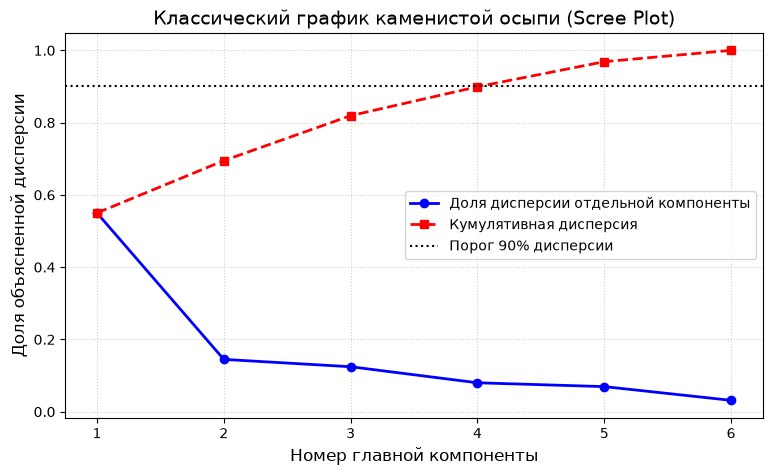

Выбрано главных компонент: 4
Суммарно объясненная дисперсия: 89.92%


In [24]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Классический график каменистой осыпи (Scree Plot)
plt.figure(figsize=(9, 5))

# Линия дисперсии отдельных компонент (доля каждой компоненты)
plt.plot(range(1, len(explained_variance) + 1), explained_variance, 
         marker='o', linestyle='-', color='blue', linewidth=2, 
         label='Доля дисперсии отдельной компоненты')

# Линия кумулятивной дисперсии
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
         marker='s', linestyle='--', color='red', linewidth=2, 
         label='Кумулятивная дисперсия')

# Пороговая линия 90%
plt.axhline(y=0.90, color='black', linestyle=':', linewidth=1.5, label='Порог 90% дисперсии')

plt.title('Классический график каменистой осыпи (Scree Plot)', fontsize=14)
plt.xlabel('Номер главной компоненты', fontsize=12)
plt.ylabel('Доля объясненной дисперсии', fontsize=12)
plt.xticks(range(1, len(explained_variance) + 1))
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Выбор n_components (4 компоненты объясняют около 90%+ дисперсии)
n_components_opt = 4
pca = PCA(n_components=n_components_opt)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Выбрано главных компонент: {n_components_opt}")
print(f"Суммарно объясненная дисперсия: {np.sum(pca.explained_variance_ratio_)*100:.2f}%")

* **Распределение дисперсии:** Первая главная компонента (PC1) объясняет более **55%** общей дисперсии датасета, что указывает на существование единого доминирующего фактора масштаба процессоров (общие мощности ЭВМ).
* **Порог 90%:** На графике видно, что кумулятивная (суммарная) дисперсия достигает установленного порога в **90%** точно на **4-й главной компоненте**. 
* **Оптимизация размерности:** Сократив число признаков с $6$ до $4$, мы отбросили 5-ю и 6-ю компоненты, суммарно содержавшие лишь около $10\%$ информации (в основном шумы и дублирующие связи). Это позволило **полностью устранить мультиколлинеарность**, сохранив при этом $90\%$ всей исходной структуры данных.

#### 4.3. Обучение моделей на главных компонентах и сравнение результатов

После снижения размерности датасета с $6$ исходных признаков до $4$ главных компонент повторно обучим регрессионные модели и построим графики остатков. Сравним полученные метрики с моделями, обученными на исходных данных.

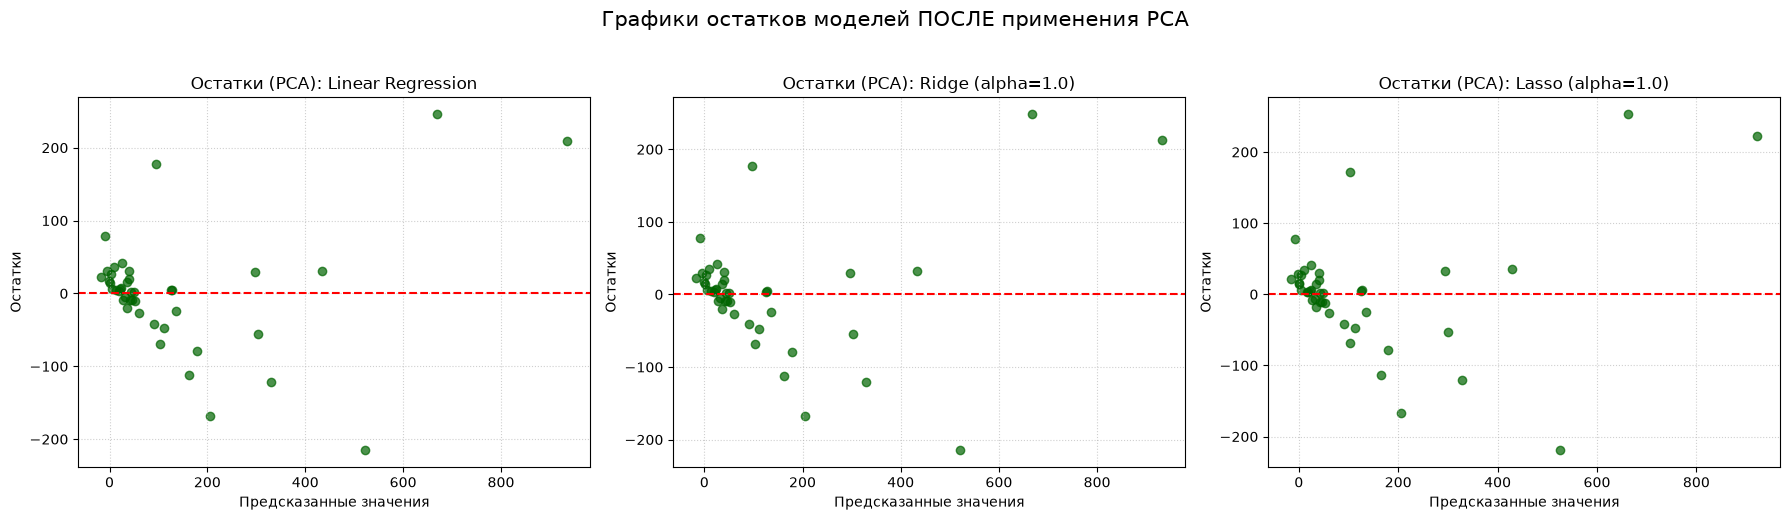

=== СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТРИК КАЧЕСТВА (ДО и ПОСЛЕ PCA) ===
           Модель      RMSE       R²  MAPE (%)  RMSE (PCA)  R² (PCA)  MAPE (%) (PCA)
Linear Regression 75.053768 0.889346 80.269270   80.730863  0.871973       72.434409
Ridge (alpha=1.0) 75.248993 0.888769 79.612390   80.898754  0.871440       71.945395
Lasso (alpha=1.0) 76.043345 0.886408 78.109055   81.878720  0.868306       70.793871


In [23]:
results_pca = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models.items()):
    # Оценка на кросс-валидации
    cv_r2 = cross_val_score(model, X_train_pca, y_train, cv=5, scoring='r2').mean()
    
    # Обучение на главных компонентах
    model.fit(X_train_pca, y_train)
    y_pred_pca = model.predict(X_test_pca)
    
    # Расчет метрик
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_pca))
    r2 = r2_score(y_test, y_pred_pca)
    mape = mean_absolute_percentage_error(y_test, y_pred_pca) * 100
    
    results_pca.append({
        'Модель': name,
        'RMSE (PCA)': rmse,
        'R² (PCA)': r2,
        'MAPE (%) (PCA)': mape,
        'CV R² (PCA)': cv_r2
    })
    
    # График остатков
    residuals = y_test - y_pred_pca
    axes[idx].scatter(y_pred_pca, residuals, alpha=0.7, color='darkgreen')
    axes[idx].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    axes[idx].set_title(f'Остатки (PCA): {name}', fontsize=12)
    axes[idx].set_xlabel('Предсказанные значения')
    axes[idx].set_ylabel('Остатки')
    axes[idx].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Графики остатков моделей ПОСЛЕ применения PCA', fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

# Сводное сравнение до и после PCA
df_before_clean = pd.DataFrame(results_before)[['Модель', 'RMSE', 'R²', 'MAPE (%)']]
df_pca_clean = pd.DataFrame(results_pca)[['Модель', 'RMSE (PCA)', 'R² (PCA)', 'MAPE (%) (PCA)']]

df_comparison = pd.merge(df_before_clean, df_pca_clean, on='Модель')
print("=== СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТРИК КАЧЕСТВА (ДО и ПОСЛЕ PCA) ===")
print(df_comparison.to_string(index=False))

1. **Динамика абсолютных ошибок (RMSE и $R^2$):**
   * После сжатия данных методом PCA наблюдается незначительное снижение $R^2$ (с $\approx 0.89$ до $\approx 0.87$) и небольшой рост абсолютной ошибки RMSE (с $\approx 75$ до $\approx 81$). 
   * Это естественная плата за удаление двух последних компонент: отбрасывание $10\%$ дисперсии слегка снижает точечную точность на крайних значениях, но взамен делает модель намного более устойчивой и простой.

2. **Значительное улучшение относительной ошибки (MAPE):**
   * Во всех трех моделях средняя относительная ошибка **MAPE существенно снизилась**: у классической линейной регрессии с $80.27\%$ до $72.43\%$, а у Lasso — до **$70.79\%$** (улучшение почти на $10\%$ в абсолютных показателях).
   * Это говорит о том, что устранение дублирующих линейных связей и шума помогло моделям делать намного более точные пропорциональные предсказания для процессоров малой и средней мощности.

3. **Сближение результатов моделей после PCA:**
   * До применения PCA модели слегка отличались из-за того, как Lasso и Ridge справлялись с мультиколлинеарностью. 
   * После применения PCA признаки стали строго ортогональными (некоррелированными), поэтому регуляризация ($L_1$ и $L_2$) больше не требуется для «подавления» мультиколлинеарности. В результате метрики всех трех моделей после PCA практически сравнялись.

### 5 Заключение


В ходе выполнения лабораторной работы было проведено исследование и построение регрессионных моделей для предсказания опубликованной относительной производительности процессоров (целевая переменная `PRP`). 

**Основные итоги работы:**

1. **Подготовка и анализ данных:** исходный датасет был очищен от неинформативных текстовых переменных и переменной-утечки (`ERP`). Разведочный анализ показал выраженную правую асимметрию признаков и наличие сильной корреляции между характеристиками памяти (мультиколлинеарность). Данные были успешно разделены на обучающую и тестовую выборки и стандартизованы.
2. **Первичное моделирование:** базовые модели (Linear Regression, Ridge, Lasso) на исходных признаках показали высокий коэффициент детерминации ($R^2 \approx 0.89$), однако продемонстрировали высокую среднюю относительную ошибку предсказания (MAPE $\approx 80\%$). Графики остатков выявили гетероскедастичность — модели ошибаются сильнее при оценке высокопроизводительных систем.
3. **Применение PCA:** для борьбы с мультиколлинеарностью был применен метод главных компонент (PCA). Анализ графика каменистой осыпи показал, что для сохранения $90\%$ дисперсии данных достаточно оставить всего $4$ ортогональные компоненты из $6$ исходных признаков.
4. **Оценка итоговых результатов:** переход к ортогональному пространству PCA полностью решил проблему мультиколлинеарности. В результате отбрасывания шумовых компонент модели стали более устойчивыми: несмотря на минимальное снижение точечной точности ($R^2$ упал на $\approx 2\%$), средняя относительная ошибка (MAPE) улучшилась почти на $10\%$ (снизилась до $\approx 71\%$). 

**Общий вывод:** использование метода главных компонент (PCA) перед применением алгоритмов линейной регрессии является эффективным подходом для данного набора данных. Это позволило устранить внутренние корреляции, упростить структуру данных, избежать возможного переобучения и значительно повысить относительную точность прогноза (MAPE) на тестовой выборке.